# 03. Basic Tree Baseline Models
This notebook implements simple non-linear tree-based regressions:
1. **Decision Tree Regressor**: Standard shallow decision tree benchmark.
2. **Random Forest Regressor**: Default bagging ensemble benchmark.
3. **LightGBM Regressor**: Default gradient boosting machine benchmark.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import lightgbm as lgb
import matplotlib.pyplot as plt

ROOT = Path("../../")
DATA_PATH = ROOT / "data/processed/01_daily_merged.csv"

def split_df(df):
    TRAIN_FRAC = 0.70
    VAL_FRAC = 0.15
    dates = np.sort(df["date"].dt.normalize().unique())
    n = len(dates)
    tc = dates[int(n * TRAIN_FRAC)]
    vc = dates[int(n * (TRAIN_FRAC + VAL_FRAC))]
    df["split"] = "test"
    df.loc[df["date"] < tc, "split"] = "train"
    df.loc[(df["date"] >= tc) & (df["date"] < vc), "split"] = "val"
    return df

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = split_df(df)

MET_COLS = [
    "temperature_2m_C_mean", "relative_humidity_pct_mean",
    "wind_speed_10m_kmh_mean", "wind_u_10m_mean", "wind_v_10m_mean",
    "precipitation_mm_sum", "cloud_cover_pct_mean", "pressure_msl_hPa_mean"
]
LAG_COLS = [
    "pm25_lag1", "pm25_lag2", "pm25_lag3", "pm25_lag7",
    "pm25_roll3", "pm25_roll7", "pm25_roll7std"
]
FEATURE_COLS = MET_COLS + LAG_COLS

train_idx = df[df["split"] == "train"].index
val_idx = df[df["split"] == "val"].index
test_idx = df[df["split"] == "test"].index

imputer = SimpleImputer(strategy="median")
X_raw = df[FEATURE_COLS].values
X_imputed = X_raw.copy()
X_imputed[train_idx] = imputer.fit_transform(X_raw[train_idx])
if len(val_idx) > 0:
    X_imputed[val_idx] = imputer.transform(X_raw[val_idx])
if len(test_idx) > 0:
    X_imputed[test_idx] = imputer.transform(X_raw[test_idx])

y = df["pm25"].values
indices = {"train": train_idx, "val": val_idx, "test": test_idx}

def evaluate_model(model, name, X_data, y_data, indices_dict):
    print(f"=== {name} ===")
    for split, idxs in indices_dict.items():
        if len(idxs) == 0: continue
        preds = model.predict(X_data[idxs])
        r2 = r2_score(y_data[idxs], preds)
        mae = mean_absolute_error(y_data[idxs], preds)
        rmse = np.sqrt(mean_squared_error(y_data[idxs], preds))
        print(f"{split.capitalize()} -> R2: {r2:.4f}, MAE: {mae:.3f}, RMSE: {rmse:.3f}")


## 1. Decision Tree Regressor

In [2]:
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_imputed[train_idx], y[train_idx])
evaluate_model(dt, "Decision Tree Regressor (max_depth=5)", X_imputed, y, indices)


=== Decision Tree Regressor (max_depth=5) ===
Train -> R2: 0.8058, MAE: 8.640, RMSE: 12.540
Val -> R2: 0.5346, MAE: 14.145, RMSE: 22.760
Test -> R2: 0.5533, MAE: 11.844, RMSE: 18.266


## 2. Random Forest Regressor

In [3]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_imputed[train_idx], y[train_idx])
evaluate_model(rf, "Random Forest Regressor (100 estimators, max_depth=10)", X_imputed, y, indices)


=== Random Forest Regressor (100 estimators, max_depth=10) ===
Train -> R2: 0.9457, MAE: 4.749, RMSE: 6.634


Val -> R2: 0.7626, MAE: 10.807, RMSE: 16.257
Test -> R2: 0.7079, MAE: 10.414, RMSE: 14.770


## 3. LightGBM Regressor (Default Hyperparameters)

In [4]:
lgbm = lgb.LGBMRegressor(random_state=42, verbosity=-1)
lgbm.fit(X_imputed[train_idx], y[train_idx])
evaluate_model(lgbm, "LightGBM Regressor (default hyperparams)", X_imputed, y, indices)


=== LightGBM Regressor (default hyperparams) ===
Train -> R2: 0.9677, MAE: 3.170, RMSE: 5.115
Val -> R2: 0.7492, MAE: 11.128, RMSE: 16.709
Test -> R2: 0.6849, MAE: 10.908, RMSE: 15.342


d:\Bussiness_plan\Multimodal_PM25\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\Bussiness_plan\Multimodal_PM25\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\Bussiness_plan\Multimodal_PM25\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 4. Feature Importance
Plot LightGBM feature importance based on split counts.

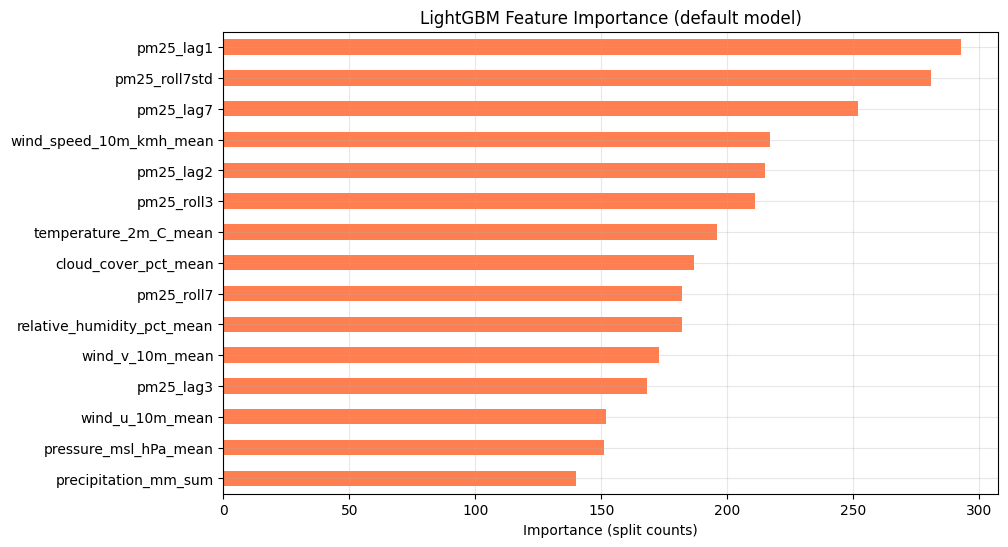

In [5]:
importances = pd.Series(lgbm.feature_importances_, index=FEATURE_COLS).sort_values()
plt.figure(figsize=(10, 6))
importances.plot(kind="barh", color="coral")
plt.title("LightGBM Feature Importance (default model)")
plt.xlabel("Importance (split counts)")
plt.grid(True, alpha=0.3)
plt.show()
